## General Parameters

In [1]:
### Load Python Lib##### 
### plot_FFcompsr_Q2max.py
### Plot form factor ratios vs. Q^2max for fits w/, w/o sum rules with stat errors.
########
import numpy as np
from math import *
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.ticker import FixedLocator, MultipleLocator, FormatStrFormatter
import os, sys, traceback

#very import to enable this so the plots can be showed in the page
get_ipython().magic(u'matplotlib inline')

# Use LaTeX font.
plt.rc('text', usetex=True)
plt.rc('font',**{'family':'serif','serif':['Computer Modern Roman'],'size':20})

import matplotlib.font_manager as font_manager
font_prop = font_manager.FontProperties( size=12)

In [2]:
## Input Parameters
Q2max = 1000
Q2str = str(Q2max)
Q2plot =10000
kmax = 12
#kmax=int(sys.argv[1])

fitdata = 'world'
#Q2max = int(raw_input('Max Q2 Fit =  '))
#Q2plot = float(raw_input('Max Q2 Plot = '))
#kmax = int(raw_input('Max Z = '))

bnd = '5'
mod = 't0fix7'
#mod='t0zero'
#mode=sys.argv[2]
GM0 = 2.79284356
GE0 = 1

In [3]:
## Dipole FF
Lambda2 = 0.71
GE0 = 1
GM0 = 2.792847356
def GD(Q2):
    return 1./(1+Q2/Lambda2)**2


## Load World+Pol Sum-Rules Fitting Results

In [5]:
##Load Q2max=1000 Fitting results#{{{
folder = '../oct03_all_FF/z'+str(kmax) # folder containing central fits
filename=folder+'/out_all_sumrules_leastsq_Q2'+Q2str+'_z'+str(kmax)+'_gb'+bnd+'_'+mod+'.dat'
if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2 = np.zeros(N, dtype=float)
GE_fit = np.zeros(N, dtype=float)
GE_pos = np.zeros(N, dtype=float)
GE_neg = np.zeros(N, dtype=float)
GM_fit = np.zeros(N, dtype=float)
GM_pos = np.zeros(N, dtype=float)
GM_neg = np.zeros(N, dtype=float)
GE_fit_rat = np.zeros(N, dtype=float)
GE_pos_rat = np.zeros(N, dtype=float)
GE_neg_rat = np.zeros(N, dtype=float)
GM_fit_rat = np.zeros(N, dtype=float)
GM_pos_rat = np.zeros(N, dtype=float)
GM_neg_rat = np.zeros(N, dtype=float)
GEGM_fit_rat = np.zeros(N, dtype=float)
GEGM_pos_rat = np.zeros(N, dtype=float)
GEGM_neg_rat = np.zeros(N, dtype=float)
GE_err = np.zeros(N, dtype=float)
GM_err = np.zeros(N, dtype=float)
GEGM_err = np.zeros(N, dtype=float)

GEd = np.zeros(N, dtype=float)
GMd = np.zeros(N, dtype=float)

for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2[i]=float(values[0])
    GE_fit[i]=float(values[2])
    GE_pos[i]=float(values[2])+abs(float(values[3]))
    GE_neg[i]=float(values[2])-abs(float(values[3]))
    GM_fit[i]=float(values[4])
    GM_pos[i]=float(values[4])+abs(float(values[5]))
    GM_neg[i]=float(values[4])-abs(float(values[5]))
      
    GE_fit_rat[i]=float(values[6])
    GE_pos_rat[i]=float(values[6])+abs(float(values[7]))
    GE_neg_rat[i]=float(values[6])-abs(float(values[7]))
    GM_fit_rat[i]=float(values[8])
    GM_pos_rat[i]=float(values[8])+abs(float(values[9]))
    GM_neg_rat[i]=float(values[8])-abs(float(values[9]))
    GEGM_fit_rat[i]=float(values[10])
    #GEGM_pos_rat[i]=float(values[10])+abs(float(values[11]))
    #GEGM_neg_rat[i]=float(values[10])-abs(float(values[11]))

    GEGM_err1 = float(values[10]) * sqrt((float(values[7])/float(values[6]))**2
                                  +(float(values[9])/float(values[8]))**2)
    GEGM_pos_rat[i]=float(values[10])+abs(GEGM_err1)
    GEGM_neg_rat[i]=float(values[10])-abs(GEGM_err1)
 
    GEd[i] = GD(Q2[i]) * GE0
    GMd[i] = GD(Q2[i]) * GM0
    GE_err[i] = abs(float(values[3]) ) #/ abs(float(values[2]))
    GM_err[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    GEGM_err[i] = GEGM_err1/float(values[10])

    #if Q2[i]>9.0 and Q2[i]<12.0:
    #    print 'Q2=%e,  GEp_ALL=%e'%(Q2[i],GE_fit_rat[i])
    
values = fitlines[2016].split()
erad = float(values[0])
derad = float(values[1])
mrad = float(values[2])
dmrad = float(values[3])

values = fitlines[2015].split()
ndof = float(values[0])
num_tot = float(values[1])
num_Mainz = float(values[2])
num_world = float(values[3])
num_pol = float(values[4])

values = fitlines[2014].split()
redchi2 = float(values[0])
chi2 = float(values[1])
chi2xsMainz = float(values[2])
chi2xsworld = float(values[3])
chi2pol = float(values[4])
chi2gecoef = float(values[5])
chi2gmcoef = float(values[6])
chi2csyst = float(values[7])
chi2NMainz = float(values[8])
chi2Nworld = float(values[9])
chi2gefake= float(values[10])
chi2gmfake= float(values[11])
chi2gefakeHQ= float(values[12])
chi2gmfakeHQ= float(values[13])

#}}}

file exist ../oct03_all_FF/z12/out_all_sumrules_leastsq_Q21000_z12_gb5_t0fix7.dat


In [10]:
## 
comp = 'all'
kmax1=12
Q2max1 = 1000 # Q2max=0.5, 1, 1.5, 2, 2.5, 3
Q2str1 = str(Q2max1) 
mod1 = 't0fix7'

folder = '../may23_%s_FF/z'%comp+str(kmax1) # folder containing central fits
filename=folder+'/out_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'.dat'

#folder = '../oct03_Mainz_FF/z'+str(kmax1) # folder containing central fits
#filename=folder+'/out_Mainz_sumrules_leastsq_Q2'+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'.dat'

if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2_n = np.zeros(N, dtype=float)
GE_fit_n = np.zeros(N, dtype=float)
GE_pos_n = np.zeros(N, dtype=float)
GE_neg_n = np.zeros(N, dtype=float)
GM_fit_n = np.zeros(N, dtype=float)
GM_pos_n = np.zeros(N, dtype=float)
GM_neg_n = np.zeros(N, dtype=float)
GE_fit_rat_n = np.zeros(N, dtype=float)
GE_pos_rat_n = np.zeros(N, dtype=float)
GE_neg_rat_n = np.zeros(N, dtype=float)
GM_fit_rat_n = np.zeros(N, dtype=float)
GM_pos_rat_n = np.zeros(N, dtype=float)
GM_neg_rat_n = np.zeros(N, dtype=float)
GEGM_fit_rat_n = np.zeros(N, dtype=float)
GEGM_pos_rat_n = np.zeros(N, dtype=float)
GEGM_neg_rat_n = np.zeros(N, dtype=float)
GE_err_n = np.zeros(N, dtype=float)
GM_err_n = np.zeros(N, dtype=float)
GEGM_err_n = np.zeros(N, dtype=float)

GEd_n = np.zeros(N, dtype=float)
GMd_n = np.zeros(N, dtype=float)

#for i in range(3,len(fitlines)-4):
for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2_n[i]=float(values[0])
    GE_fit_n[i]=float(values[2])
    GE_pos_n[i]=float(values[2])+abs(float(values[3]))
    GE_neg_n[i]=float(values[2])-abs(float(values[3]))
    GM_fit_n[i]=float(values[4])
    GM_pos_n[i]=float(values[4])+abs(float(values[5]))
    GM_neg_n[i]=float(values[4])-abs(float(values[5]))
      
    GE_fit_rat_n[i]=float(values[6])
    GE_pos_rat_n[i]=float(values[6])+abs(float(values[7]))
    GE_neg_rat_n[i]=float(values[6])-abs(float(values[7]))
    GM_fit_rat_n[i]=float(values[8])
    GM_pos_rat_n[i]=float(values[8])+abs(float(values[9]))
    GM_neg_rat_n[i]=float(values[8])-abs(float(values[9]))
    GEGM_fit_rat_n[i]=float(values[10])
    #GEGM_pos_rat[i]=float(values[10])+abs(float(values[11]))
    #GEGM_neg_rat[i]=float(values[10])-abs(float(values[11]))

    GEGM_err_n1 = float(values[10]) * sqrt((float(values[7])/float(values[6]))**2
                                  +(float(values[9])/float(values[8]))**2)
    GEGM_pos_rat_n[i]=float(values[10])+abs(GEGM_err_n1)
    GEGM_neg_rat_n[i]=float(values[10])-abs(GEGM_err_n1)
 
    GEd_n[i] = GD(Q2_n[i]) * GE0
    GMd_n[i] = GD(Q2_n[i]) * GM0
    GE_err_n[i] = abs(float(values[3]) ) #/ abs(float(values[2]))
    GM_err_n[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    GEGM_err_n[i] = GEGM_err_n1/float(values[10])

values = fitlines[2016].split()
erad_n = float(values[0])
derad_n = float(values[1])
mrad_n = float(values[2])
dmrad_n = float(values[3])

values = fitlines[2015].split()
ndof_n = float(values[0])
num_tot_n = float(values[1])
num_Mainz_n = float(values[2])
num_world_n = float(values[3])
num_pol_n = float(values[4])

values = fitlines[2014].split()
redchi2_n = float(values[0])
chi2_n = float(values[1])
chi2xsMainz_n = float(values[2])
chi2xsworld_n = float(values[3])
chi2pol_n = float(values[4])
chi2gecoef_n = float(values[5])
chi2gmcoef_n = float(values[6])
chi2csyst_n = float(values[7])
chi2NMainz_n = float(values[8])
chi2Nworld_n = float(values[9])
chi2gefake_n= float(values[10])
chi2gmfake_n= float(values[11])
chi2gefakeHQ_n= float(values[12])
chi2gmfakeHQ_n= float(values[13])

#}}}

file exist ../may23_all_FF/z12/out_all_sumrules_leastsq_Q21000_z12_gb5_t0fix7.dat


## Load $G_E^p$ and $G_M^p$world data

In [11]:
## Load GE&GM world data
## from John's paper Phy. Rev. C 76 035205(2007)
#########################{{{
def loadGEGM(Q2_max):
    fitlines = open('../data/proton/old/GEGM_John.dat', 'r').readlines()
    N=len(fitlines)-1 + 4
    Q2=np.zeros(N, dtype=float)
    GEdip=np.zeros(N, dtype=float)
    dGEdip=np.zeros(N, dtype=float)
    GMdip=np.zeros(N, dtype=float)
    dGMdip=np.zeros(N, dtype=float)
    GEGMdip=np.zeros(N, dtype=float)
    dGEGMdip=np.zeros(N, dtype=float)
    for i in range(0,len(fitlines)-1):
        values = fitlines[i+1].split()
        try:#eliminates descriptions in 1st line of file
            Q2test=float(values[0])
        except:
            continue

        if Q2test>Q2_max:
            continue

        Q2[i]=float(values[0])
        GEdip[i]=float(values[1])
        dGEdip[i]=float(values[2])
        GMdip[i]=float(values[3])
        dGMdip[i]=float(values[4])
        GEGMdip[i]=float(values[5])
        dGEGMdip[i]=float(values[6])

#     lines1= open('../data/proton/prot_GEGM_fake.dat').readlines()
#     values1=lines1[2].split()
#     Q2[N-1]=float(values1[0])
#     GEdip[N-1]=float(values1[1])
#     dGEdip[N-1]=float(values1[2])
#     GMdip[N-1]=float(values1[3])
#     dGMdip[N-1]=float(values1[4])
#     #GEGMdip[N-1]=float(values1[5])
#     #dGEGMdip[N-1]=float(values1[6])  
#     GEGMdip[N-1]= -1000.0
#     dGEGMdip[N-1]= 0.0

    K=N-1
    lines2= open('../data/proton/prot_GEGM_fakeHQ_sep20.dat').readlines()
    values1=lines2[0].split()
    Q2[K]=float(values1[0])
    GEdip[K]=float(values1[1])
    dGEdip[K]=float(values1[2])
    GMdip[K]=float(values1[3])
    dGMdip[K]=float(values1[4])
    #GEGMdip[K]=float(values1[5])
    #dGEGMdip[K]=float(values1[6])  
    GEGMdip[K]= -1000.0
    dGEGMdip[K]= 0.0

    K=N-2
    values1=lines2[1].split()
    Q2[K]=float(values1[0])
    GEdip[K]=float(values1[1])
    dGEdip[K]=float(values1[2])
    GMdip[K]=float(values1[3])
    dGMdip[K]=float(values1[4])
    #GEGMdip[K]=float(values1[5])
    #dGEGMdip[K]=float(values1[6])  
    GEGMdip[K]= -1000.0
    dGEGMdip[K]= 0.0
    
    K=N-3
    values1=lines2[2].split()
    Q2[K]=float(values1[0])
    GEdip[K]=float(values1[1])
    dGEdip[K]=float(values1[2])
    GMdip[K]=float(values1[3])
    dGMdip[K]=float(values1[4])
    #GEGMdip[K]=float(values1[5])
    #dGEGMdip[K]=float(values1[6])  
    GEGMdip[K]= -1000.0
    dGEGMdip[K]= 0.0

    K=N-4
    values1=lines2[3].split()
    Q2[K]=float(values1[0])
    GEdip[K]=float(values1[1])
    dGEdip[K]=float(values1[2])
    GMdip[K]=float(values1[3])
    dGMdip[K]=float(values1[4])
    #GEGMdip[K]=float(values1[5])
    #dGEGMdip[K]=float(values1[6])  
    GEGMdip[K]= -1000.0
    dGEGMdip[K]= 0.0
    
    return Q2, GEdip, dGEdip, GMdip, dGMdip, GEGMdip, dGEGMdip
#######################
##Read GE/GD, GM/nuGD, and GE/GM from John's 2007 paper
Q2_data, GEdip_data, dGEdip_data, GMdip_data, dGMdip_data, GEGMdip_data,dGEGMdip_data=loadGEGM(Q2plot)


#print 'Q2_John:', Q2_datab
#}}}

## Load $G_E^p$ and $G_M^p$ polarization data

In [12]:
# Load GE/GM Polarization data
#####################{{{
def loadPolGEGM(Q2_max):
    Q2=[]
    R=[]
    dR_Err=[]
    #idat=[]
    lines= open('../data/proton/World_GeGm_Polarization.dat').readlines()
    for i in range(1, len(lines)):
        values=lines[i].split()
        try:#eliminates descriptions in 1st line of file
            Q2test=float(values[0])
        except:
            continue
        if Q2test>Q2_max:
            continue
        
        Q2.append(float(values[0]))
        R.append(float(values[1]))
        dR_Err.append(sqrt((float(values[2]))**2+(float(values[3]))**2))
        #idat.append(int(values[4]))
    
    return Q2, R, dR_Err

Q2_pol, GEGMrat_pol,dGEGMrat_pol=loadPolGEGM(Q2plot)

Q2_pol=np.array(Q2_pol, dtype=float)
GEGMrat_pol=np.array(GEGMrat_pol, dtype=float)
dGEGMrat_pol=np.array(dGEGMrat_pol, dtype=float)
#}}}


## Plot $G_E^p/G_D$, $G_M^p/\mu_p G_D$ and $\mu_p G_E^p/G_M^p$ 

In [13]:
comp1='All'
comp2='AP17'

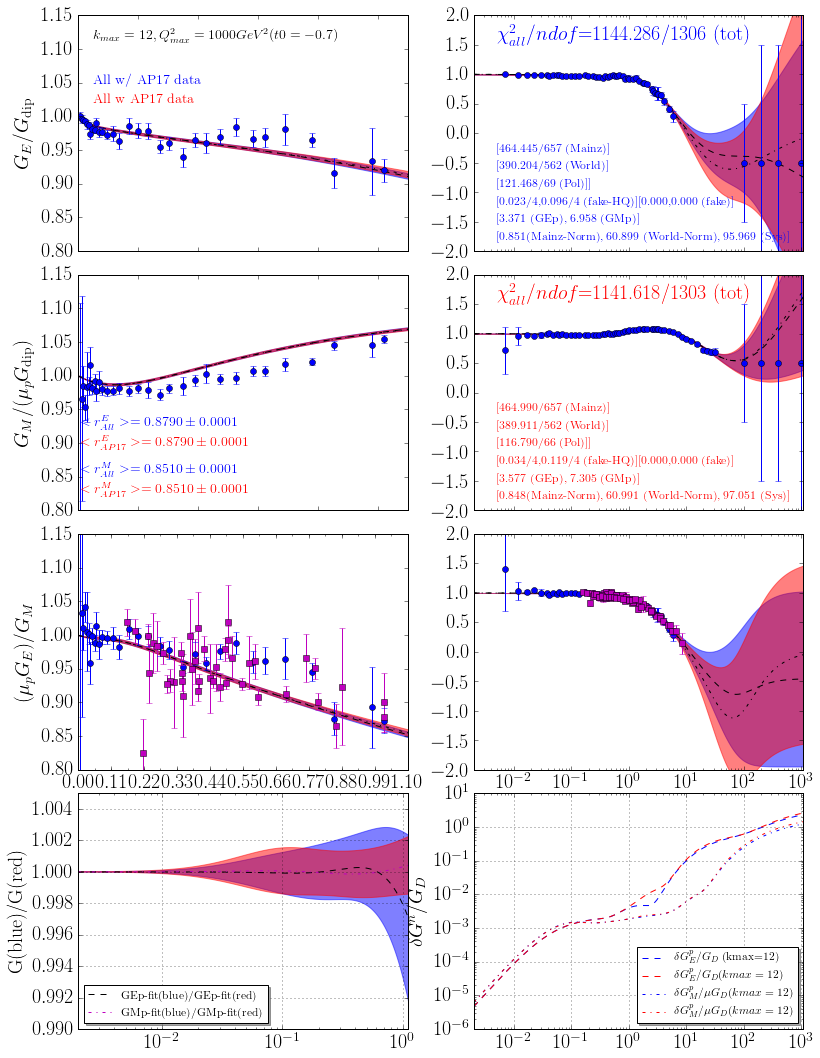

In [19]:
## Plot GE/GD, GM/muGD and GE/GM##########{{{
#Plot Range{{{
ymin1 = 0.8
#ymin_GErat = np.amin(GEdip_data)-np.amax(dGEdip_data)
ymax1 = 1.15 #np.amax(GEdip_data)*1.02

ymin2 =-2.0
#ymin_GMrat = np.amin(GMdip_data)-np.amax(dGMdip_data)
ymax2 = 2. #np.amax(GMdip_data)*1.02

Q2plot0=1+0.1
#if Q2max<1:
#    Q2plot0=1.1
    
Q2plot1=1100
#Q2plot1=Q2plot
#}}}

com1 = 'kmax=12'
com2 = 'kmax=12'
#com2 = 'kmax=12, no-High-Q2-Point'

font_prop = font_manager.FontProperties( size=12)
font_prop1 = font_manager.FontProperties( size=14)

f1, axes = plt.subplots(nrows=4, ncols=2, figsize=(13,16))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)

#######  Subplot for GE.
axes[0,0].plot(Q2, GE_fit_rat, 'k--', color='black',  label=com1)
axes[0,0].fill_between(Q2, GE_neg_rat, GE_pos_rat, edgecolor='blue',facecolor='blue',alpha=0.5)

axes[0,0].plot(Q2_n, GE_fit_rat_n, 'k-.', color='black',  label=com2)
axes[0,0].fill_between(Q2_n, GE_neg_rat_n, GE_pos_rat_n, edgecolor='r',facecolor='r',alpha=0.5)

axes[0,0].errorbar(Q2_data, GEdip_data, yerr=dGEdip_data, fmt='o')

axes[0,0].set_xlim(0.0, Q2plot0)
axes[0,0].set_ylabel('$G_E/G_{\mathrm{dip}}$') # label, y-axis
axes[0,0].set_ylim(ymin1, ymax1)


#########
axes[0,1].plot(Q2, GE_fit_rat, 'k--', color='black',  label=com1)
axes[0,1].fill_between(Q2, GE_neg_rat, GE_pos_rat, edgecolor='blue',facecolor='blue',alpha=0.5)

axes[0,1].plot(Q2_n, GE_fit_rat_n, 'k-.', color='black',  label=com2)
axes[0,1].fill_between(Q2_n, GE_neg_rat_n, GE_pos_rat_n, edgecolor='r',facecolor='r',alpha=0.5)

axes[0,1].errorbar(Q2_data, GEdip_data, yerr=dGEdip_data, fmt='o')

axes[0,1].set_xlim(2e-3, Q2plot1)
#axes[0,1].set_ylabel('$G_E/G_{\mathrm{dip}}$') # label, y-axis
axes[0,1].set_ylim(ymin2,ymax2)
axes[0,1].set_xscale('log')

#######  Subplot for GM.
axes[1,0].plot(Q2, GM_fit_rat, 'k--', color='black',  label=com1)
axes[1,0].fill_between(Q2, GM_neg_rat, GM_pos_rat, edgecolor='blue',facecolor='blue',alpha=0.5)

axes[1,0].plot(Q2_n, GM_fit_rat_n, 'k-.', color='black',  label=com2)
axes[1,0].fill_between(Q2_n, GM_neg_rat_n, GM_pos_rat_n, edgecolor='r',facecolor='r',alpha=0.5)

axes[1,0].errorbar(Q2_data, GMdip_data, yerr=dGMdip_data, fmt='o')

axes[1,0].set_xlim(0.0, Q2plot0)
axes[1,0].set_ylabel('$G_M/(\mu_p G_{\mathrm{dip}})$') # label, y-axis
axes[1,0].set_ylim(0.8, ymax1)


###########
axes[1,1].plot(Q2, GM_fit_rat, 'k--', color='black',  label=com1)
axes[1,1].fill_between(Q2, GM_neg_rat, GM_pos_rat, edgecolor='blue',facecolor='blue',alpha=0.5)

axes[1,1].plot(Q2_n, GM_fit_rat_n, 'k-.', color='black',  label=com2)
axes[1,1].fill_between(Q2_n, GM_neg_rat_n, GM_pos_rat_n, edgecolor='r',facecolor='r',alpha=0.5)

axes[1,1].errorbar(Q2_data, GMdip_data, yerr=dGMdip_data, fmt='o')

axes[1,1].set_xlim(2e-3, Q2plot1)
#axes[1,1].set_ylabel('$G_M/(\mu_p G_{\mathrm{dip}})$') # label, y-axis
axes[1,1].set_ylim(ymin2,ymax2)
axes[1,1].set_xscale('log')


####### Subplot for GE/GM
axes[2,0].plot(Q2, GEGM_fit_rat, 'k--', color='black',  label=com1)
axes[2,0].fill_between(Q2, GEGM_neg_rat, GEGM_pos_rat, edgecolor='blue',facecolor='blue',alpha=0.5)

axes[2,0].plot(Q2_n, GEGM_fit_rat_n, 'k-.', color='black',  label=com2)
axes[2,0].fill_between(Q2_n, GEGM_neg_rat_n, GEGM_pos_rat_n, edgecolor='r',facecolor='r',alpha=0.5)

axes[2,0].errorbar(Q2_data, GEGMdip_data, yerr=dGEGMdip_data, fmt='o')
axes[2,0].errorbar(Q2_pol, GEGMrat_pol, yerr=dGEGMrat_pol, fmt='s', color='m')

axes[2,0].set_xlim(0.0, Q2plot0)
axes[2,0].set_ylabel('$(\mu_p G_E)/G_M$') # label, y-axis
#axes[2,0].set_ylim(ymin1, ymax1)
axes[2,0].set_ylim(0.8, ymax1)


#########
axes[2,1].plot(Q2, GEGM_fit_rat, 'k--', color='black',  label=com1)
axes[2,1].fill_between(Q2, GEGM_neg_rat, GEGM_pos_rat, edgecolor='blue',facecolor='blue',alpha=0.5)

axes[2,1].plot(Q2_n, GEGM_fit_rat_n, 'k-.', color='black',  label=com2)
axes[2,1].fill_between(Q2_n, GEGM_neg_rat_n, GEGM_pos_rat_n, edgecolor='r',facecolor='r',alpha=0.5)

axes[2,1].errorbar(Q2_data, GEGMdip_data, yerr=dGEGMdip_data, fmt='o')
axes[2,1].errorbar(Q2_pol, GEGMrat_pol, yerr=dGEGMrat_pol, fmt='s', color='m')

axes[2,1].set_xlim(2e-3, Q2plot1)
#axes[2,1].set_ylabel('$(\mu_p G_E)/G_M$') # label, y-axis
axes[2,1].set_ylim(ymin2, ymax2)
axes[2,1].set_xscale('log')


########
axes[3,0].plot(Q2, GE_fit_rat/GE_fit_rat_n, 'k--', color='black',  label='GEp-fit(blue)/GEp-fit(red)')
axes[3,0].plot(Q2, GM_fit_rat/GM_fit_rat_n, 'k-.', color='m',  label='GMp-fit(blue)/GMp-fit(red)')

axes[3,0].fill_between(Q2, GE_neg_rat_n/GE_fit_rat_n*GE_fit_rat/GE_fit_rat_n, GE_pos_rat_n/GE_fit_rat_n*GE_fit_rat/GE_fit_rat_n, edgecolor='blue',facecolor='blue',alpha=0.5)
axes[3,0].fill_between(Q2, GM_neg_rat_n/GM_fit_rat_n*GM_fit_rat/GM_fit_rat_n, GM_pos_rat_n/GM_fit_rat_n*GM_fit_rat/GM_fit_rat_n, edgecolor='red',facecolor='red',alpha=0.5)


axes[3,0].set_xlim(2e-3, Q2plot0)
axes[3,0].set_ylabel('G(blue)/G(red)') # label, y-axis
axes[3,0].set_ylim(0.99,1.005)
axes[3,0].set_xscale('log')
axes[3,0].grid()

axes[3,1].plot(Q2, (GE_pos_rat-GE_fit_rat), 'k--', color='blue',  label='$\delta G_E^p/G_D$ (%s)'%com1)
axes[3,1].plot(Q2, (GE_pos_rat_n-GE_fit_rat_n), 'k--', color='r',  label='$\delta G_E^p/G_D (%s)$'%com2)

axes[3,1].plot(Q2, (GM_pos_rat-GM_fit_rat), 'k-.', color='blue',  label='$\delta G_M^p/\mu G_D (%s)$'%com1)
axes[3,1].plot(Q2, (GM_pos_rat_n-GM_fit_rat_n), 'k-.', color='r',  label='$\delta G_M^p/\mu G_D (%s)$'%com2)


axes[3,1].set_xlim(2e-3, Q2plot1)
axes[3,1].set_ylabel('$\delta G^n/G_D$') # label, y-axis
axes[3,1].set_ylim(1e-6,1e1)
axes[3,1].set_xscale('log')
axes[3,1].set_yscale('log')
axes[3,1].grid()


#######  x-axis labelling, etc.
plt.setp(axes[0,0].get_xticklabels(), visible=False)
plt.setp(axes[0,1].get_xticklabels(), visible=False)
plt.setp(axes[1,0].get_xticklabels(), visible=False)
plt.setp(axes[1,1].get_xticklabels(), visible=False)

axes[2,0].set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$') # label, x-axis
axes[2,0].xaxis.set_major_locator(MultipleLocator(Q2plot0/10))
axes[2,0].xaxis.set_minor_locator(MultipleLocator(Q2plot0/20))
if Q2max1<10:
    axes[2,0].xaxis.set_major_locator(MultipleLocator(Q2plot0/5))
    axes[2,0].xaxis.set_minor_locator(MultipleLocator(Q2plot0/10))

axes[2,1].set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$') # label, x-axis

y0 = 0.92
i0=0
x0 = 0.01
axes[1,0].text(x0, y0-0.02*i0,  r'$<r^{E}_{%s}>=%5.4f\pm %5.4f$'%(comp1,erad,derad),
              fontproperties=font_prop1, color='blue')
i0+=1.5
axes[1,0].text(x0, y0-0.02*i0,  r'$<r^{E}_{%s}>=%5.4f\pm %5.4f$'%(comp2,erad_n,derad_n),
              fontproperties=font_prop1, color='r')
i0+=2
axes[1,0].text(x0, y0-0.02*i0,  r'$<r^{M}_{%s}>=%5.4f\pm %5.4f$'%(comp1,mrad, dmrad),
              fontproperties=font_prop1, color='blue')
i0+=1.5
axes[1,0].text(x0, y0-0.02*i0,  r'$<r^{M}_{%s}>=%5.4f\pm %5.4f$'%(comp2,mrad_n, dmrad_n),
              fontproperties=font_prop1, color='r')

#{{{Ploting Range and texts
y1 = 1.5
i1=0
x1 = 0.005
axes[0,1].text(x1, y1-0.3*i1, r'$\chi^{2}_{all}/ndof$=%5.3f/%d (tot)'%(chi2, ndof),
               color='blue')
axes[1,1].text(x1, y1-0.3*i1, r'$\chi^{2}_{all}/ndof$=%5.3f/%d (tot)'%(chi2_n, ndof_n),
               color='r')
y1 = 0.0
i1+=1
axes[0,1].text(x1, y1-0.3*i1, r'[%5.3f/%d (Mainz)]'
         %(chi2xsMainz, num_Mainz), 
          fontproperties=font_prop, color='blue')
axes[1,1].text(x1, y1-0.3*i1, r'[%5.3f/%d (Mainz)]'
         %(chi2xsMainz_n, num_Mainz_n), 
          fontproperties=font_prop, color='r')
i1+=1
axes[0,1].text(x1, y1-0.3*i1, r'[%5.3f/%d (World)]'
         %(chi2xsworld,num_world), 
          fontproperties=font_prop, color='blue')
axes[1,1].text(x1, y1-0.3*i1, r'[%5.3f/%d (World)]'
         %(chi2xsworld_n,num_world_n), 
          fontproperties=font_prop, color='r')
i1+=1
axes[0,1].text(x1, y1-0.3*i1, r'[%5.3f/%d (Pol)]]'
         %(chi2pol, num_pol), 
          fontproperties=font_prop, color='blue')
axes[1,1].text(x1, y1-0.3*i1, r'[%5.3f/%d (Pol)]]'
         %(chi2pol_n, num_pol_n), 
          fontproperties=font_prop, color='r')
i1+=1
axes[0,1].text(x1, y1-0.3*i1, r'[%5.3f/4,%5.3f/4 (fake-HQ)][%5.3f,%5.3f (fake)]'
         %(chi2gefakeHQ, chi2gmfakeHQ,chi2gefake,chi2gmfake), 
          fontproperties=font_prop, color='blue')
axes[1,1].text(x1, y1-0.3*i1, r'[%5.3f/4,%5.3f/4 (fake-HQ)][%5.3f,%5.3f (fake)]'
         %(chi2gefakeHQ_n, chi2gmfakeHQ_n,chi2gefake_n,chi2gmfake_n), 
          fontproperties=font_prop, color='r')
i1+=1
axes[0,1].text(x1, y1-0.3*i1, r'[%5.3f (GEp), %5.3f (GMp)]'
         %(chi2gecoef, chi2gmcoef), 
          fontproperties=font_prop, color='blue')
axes[1,1].text(x1, y1-0.3*i1, r'[%5.3f (GEp), %5.3f (GMp)]'
         %(chi2gecoef_n, chi2gmcoef_n), 
          fontproperties=font_prop, color='r')
i1+=1
axes[0,1].text(x1, y1-0.3*i1, r'[%5.3f(Mainz-Norm), %5.3f (World-Norm), %5.3f (Sys)]'
         %(chi2NMainz,chi2Nworld,chi2csyst), 
          fontproperties=font_prop, color='blue')
axes[1,1].text(x1, y1-0.3*i1, r'[%5.3f(Mainz-Norm), %5.3f (World-Norm), %5.3f (Sys)]'
         %(chi2NMainz_n,chi2Nworld_n,chi2csyst_n), 
          fontproperties=font_prop, color='r')
lg = axes[3,0].legend(loc='lower left', shadow='true', fontsize='xx-small',numpoints=1)
lg2 = axes[3,1].legend(loc='lower right', shadow='true', fontsize='xx-small',numpoints=1)



axes[0,0].text(0.05, 1.11, r'$k_{max}=%d, Q^2_{max}=%s GeV^2 (%s)$'%(kmax,Q2str,"t0=-0.7"),
               fontproperties=font_prop1,color='black')
#axes[0,0].text(0.05, 1.08, r'$k_{max}=%d, Q^2_{max}=%s GeV^2 (%s)$'%(kmax,Q2str1,"t0=-0.7"),
#               fontproperties=font_prop1,color='red')
axes[0,0].text(0.05, 1.05, r'All w/ AP17 data', fontproperties=font_prop1,color='blue')
axes[0,0].text(0.05, 1.02, r'All w AP17 data', fontproperties=font_prop1,color='red')


plt.savefig('Com_all_%s-Old.pdf'%comp2)
plt.savefig('Com_all_%s-Old.png'%comp2)

#}}}